In [1]:
from twolenspy.HDPE_lens import HDEP_2lens
import h5py as h5
import numpy as np
import torch as T

8


### 1. ARC vs NO ARC at 90GHz which is the ARC designed Frequency

In [2]:
Polar_offset= {'AR':{}, 'noAR':{}}
dx_list = [0,20,40,60,80,100,120]
PO_sampling_file = 'twolenspy/HDPE_PO_points.h5'

In [3]:
AR_file = 'AR_LIB/HDPE_ARC2.h5'
frequency = '120GHz'

In [4]:
freq_list= [120]
for freq in freq_list:
    Model1 = HDEP_2lens(freq,
                    feedpos = [0,0,0],
                    feedrot = [0,0,45],
                    AR_file = AR_file,
                    groupname= frequency,
                    outputfolder = '../Data4/HDPE/'+'AR'+'/'+str(freq)+'GHz/')
    with h5.File(PO_sampling_file,'r') as f:
        PO_no = f[str(freq)+'GHz'][str(0)][str(45)]['POpoints'][:]
        print(PO_no[4])
    factor = 1
    Model1.run_po(np.array(PO_no[0:2],dtype =np.int32)*factor ,
                          np.array(PO_no[2:4],dtype =np.int32)*factor ,
                          Lyot_N=np.array([PO_no[4][0]*factor ,PO_no[4][1]*factor ],dtype =np.int32),
                         sampling_type = 'less',device = T.device('cuda'))



[108 285]
Batch size: 97


100%|██████████| 200/200 [00:04<00:00, 40.66it/s]


Here
Batch size: 458


100%|██████████| 167/167 [00:03<00:00, 48.40it/s]


Batch size: 115


...

100%|██████████| 96/96 [00:02<00:00, 47.33it/s]


Here
Batch size: 125


100%|██████████| 160/160 [00:03<00:00, 47.08it/s]


*(**)
Batch size: 1486


100%|██████████| 27/27 [00:00<00:00, 638.92it/s]


Vector(numpy, shape=(3, 40401))
Gain 48.41390581489633
45.40360965966366 45.403602056846054
True -76.73082701522301
rotation angle method 3:  [-89.99998288] 0 45
[-44.99998288]


e:\E_Laptop_new\project_Iceland\Program_project\hypo\src\twolenspy\HDPE_lens.py:224: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p1 = ax[0].pcolor(x,y, 10*np.log10(np.abs(E_co.reshape(Ny,Nx))**2),vmax = vmax,vmin= vmax-80,cmap = cmap)
e:\E_Laptop_new\project_Iceland\Program_project\hypo\src\twolenspy\HDPE_lens.py:227: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p2 = ax[1].pcolor(x,y, 10*np.log10(np.abs(E_cx.reshape(Ny,Nx))**2),vmax = vmax,vmin= vmax-80,c

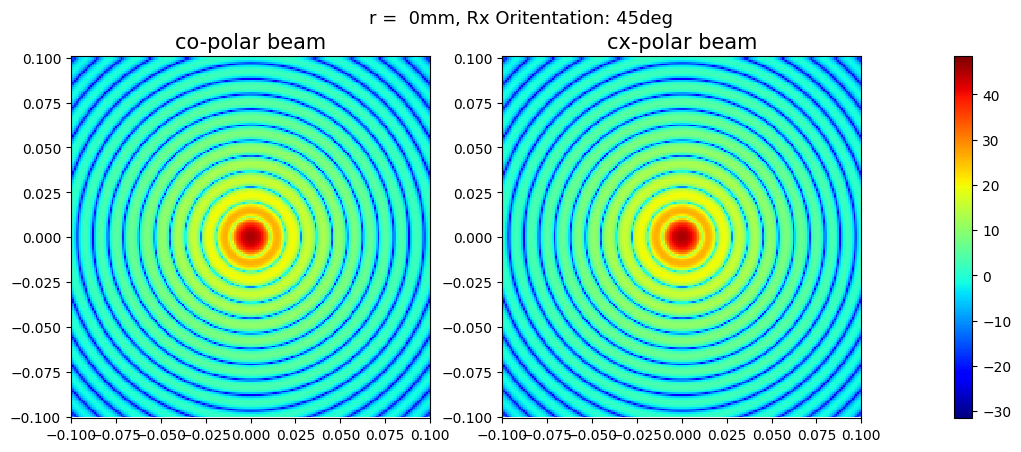

e:\E_Laptop_new\project_Iceland\Program_project\hypo\src\twolenspy\HDPE_lens.py:253: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p3 = ax[0].pcolor(x,y, 10*np.log10(np.abs(E_co_new.reshape(Ny,Nx))**2),vmax = vmax,vmin= vmax-80,cmap = cmap)
e:\E_Laptop_new\project_Iceland\Program_project\hypo\src\twolenspy\HDPE_lens.py:254: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p4 = ax[1].pcolor(x,y, 10*np.log10(np.abs(E_cx_new.reshape(Ny,Nx))**2),vmax = vmax,vmin= v

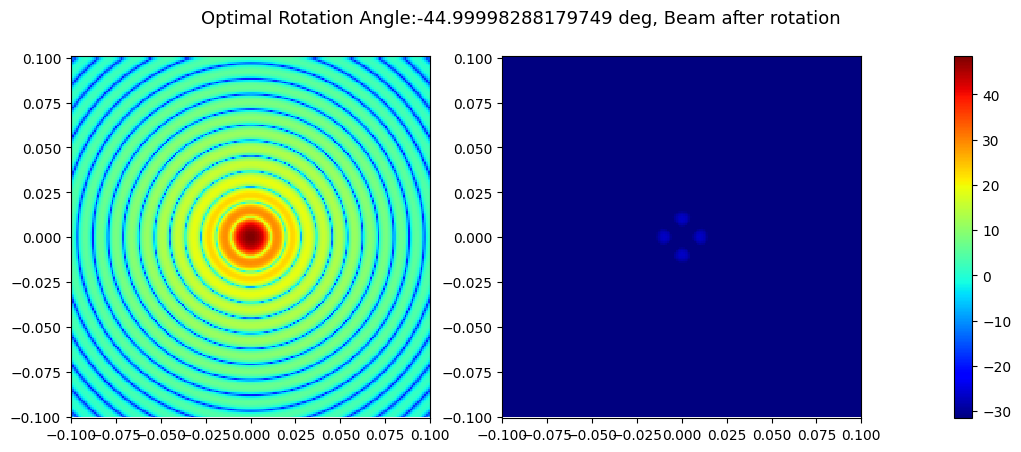

(array([-89.99998288]),
 array([0.52529138+0.37078538j, 0.26646457+0.32919158j,
        0.02407725+0.19230529j, ..., 0.02434808+0.19245783j,
        0.26664046+0.32934454j, 0.52537266+0.37096698j]),
 array([ 4.08278230e-05+1.39462045e-06j, -5.27359408e-05-7.82721881e-05j,
        -7.29265924e-05-1.92393801e-04j, ...,
        -8.46509760e-05-1.13025977e-04j, -9.35381654e-05+1.00996842e-05j,
        -2.63873440e-05+1.04753827e-04j]))

In [5]:
Model1.plot_beam()